In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [3]:
X , y = make_classification(n_features=5 , n_redundant=0 , n_informative=5 , n_clusters_per_class=1)

In [5]:
df = pd.DataFrame(X , columns=['col1' , 'col2' , 'col3' , 'col4' , 'col5'])

In [7]:
df['target'] = y

In [8]:
df

,col1,col2,col3,col4,col5,target
0,-0.204561,-0.175664,2.795294,-1.620467,-0.084925,1
1,1.376086,-3.513673,3.190941,-2.827918,0.132473,1
2,0.068024,0.347606,0.375041,-1.131809,0.931103,1
3,-1.353493,0.253789,-1.117338,0.465494,0.083404,0
4,-0.698384,1.452490,0.618865,1.698795,1.172487,0
...,...,...,...,...,...,...
95,-2.148082,0.718488,2.175756,1.061516,1.731940,0
96,-0.366286,0.619210,1.574477,0.651579,-0.010900,1
97,1.408430,2.215706,-2.244508,0.460049,2.893111,1
98,0.304697,-1.959179,3.043198,-2.329646,-0.303361,1


In [22]:
def sample_row(df , percent):
    return df.sample(int(percent * df.shape[0]) , replace = True)


In [ ]:
# function for feautre sampling 
def sample_feature(df , percent):
    cols = random.sample(df.columns.tolist()[: , -1] , int(percent * df.shape[1]))
    return df[cols]

In [15]:
def combined_sampling(df , row_percent , col_percent):
    new_df = sample_row(df , row_percent)
    return sample_feature(df , col_percent)


In [24]:
df1 = sample_row(df , 0.1)                                                                                   

In [28]:
df2 = sample_row(df , 0.1)
df3 = sample_row(df , 0.1)

In [29]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 =  DecisionTreeClassifier()
clf3 =  DecisionTreeClassifier()

In [38]:
clf1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:5],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:5],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

[Text(0.5, 0.75, 'x[3] <= -0.181\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.625, 0.5, '  False')]

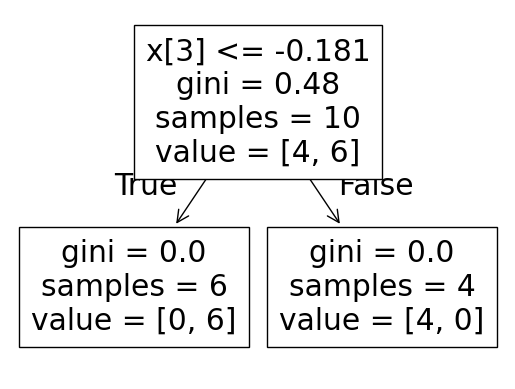

In [39]:
from sklearn.tree import plot_tree

plot_tree(clf1)

[Text(0.4, 0.875, 'x[3] <= 0.604\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.2, 0.625, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.30000000000000004, 0.75, 'True  '),
 Text(0.6, 0.625, 'x[3] <= 0.939\ngini = 0.278\nsamples = 6\nvalue = [5, 1]'),
 Text(0.5, 0.75, '  False'),
 Text(0.4, 0.375, 'x[2] <= -1.603\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.2, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.375, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]')]

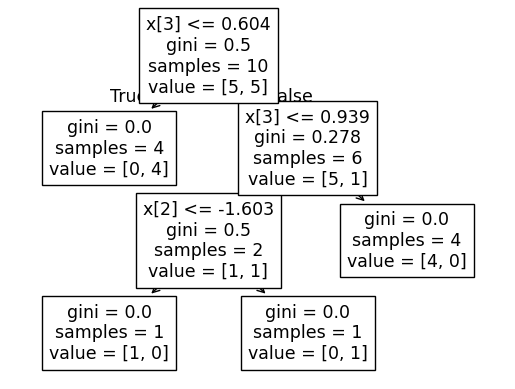

In [40]:
plot_tree(clf2)

In [42]:
clf1.predict(np.array([0.551380,-1.876815,-1.807618,-1.557932,-0.039809]).reshape(1,5))

/home/sudhanshu-jain/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [43]:
clf2.predict(np.array([0.551380,-1.876815,-1.807618,-1.557932,-0.039809]).reshape(1,5))

/home/sudhanshu-jain/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [44]:
clf3.predict(np.array([0.551380,-1.876815,-1.807618,-1.557932,-0.039809]).reshape(1,5))

/home/sudhanshu-jain/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])